<div style="background:#0D2137;padding:32px 36px 24px;border-radius:8px;margin-bottom:8px">
<h1 style="color:#FFFFFF;font-size:22px;font-weight:700;margin:0 0 10px">21 CFR Part 211 — GMP Internal Audit & Compliance Tracker</h1>
<p style="color:#90CAF9;font-size:13px;margin:0 0 4px">FDA Regulatory Compliance  &nbsp;·&nbsp;  Six-Department Audit  &nbsp;·&nbsp;  Risk-Based Finding Classification</p>
</div>
<div style="background:#F0F4F8;border-left:4px solid #00838F;padding:14px 18px;border-radius:0 6px 6px 0;margin-bottom:4px">
<table style="width:100%;font-size:13px;border-collapse:collapse">
<tr><td style="color:#546E7A;width:140px"><b>Author</b></td><td style="color:#0D2137">Harshitha Gudavalli</td></tr>
<tr><td style="color:#546E7A"><b>Degree</b></td><td style="color:#0D2137">M.S. Biomedical Engineering &amp; Biotechnology</td></tr>
<tr><td style="color:#546E7A"><b>Standard</b></td><td style="color:#0D2137">21 CFR Part 211 — Current Good Manufacturing Practice (cGMP)</td></tr>
<tr><td style="color:#546E7A"><b>Stack</b></td><td style="color:#0D2137">Python &nbsp;·&nbsp; pandas &nbsp;·&nbsp; NumPy &nbsp;·&nbsp; Matplotlib &nbsp;·&nbsp; openpyxl</td></tr>
</table>
</div>

---
## Project Background

FDA internal audits are one of the most critical quality activities in pharmaceutical manufacturing. Under **21 CFR Part 211** (Current Good Manufacturing Practice), companies are required to maintain systems that ensure every aspect of production — from raw material receipt to batch release — meets regulatory standards.

When the FDA conducts an inspection, they review the same requirements that internal QA teams audit regularly. Companies that maintain strong internal audit programs catch gaps before the FDA does — avoiding Warning Letters, consent decrees, and product recalls.

This project builds a complete internal audit tracking system that:
- Maps **55 audit requirements** directly to specific 21 CFR Part 211 sections
- Evaluates compliance across **6 departments**: QA, Production, QC, Warehouse, Maintenance, Document Control
- Assigns **risk-based finding classification**: Critical, Major, or Observation
- Calculates **weighted compliance scores** by department (higher-weight requirements carry more impact)
- Generates a professional audit summary report in Excel

> All audit data is simulated for demonstration purposes.

---
## Finding Classification Reference

| Classification | Definition | Response Required |
|---|---|---|
| **Critical** | Direct risk to patient safety or product integrity | Immediate CAPA; possible batch hold |
| **Major** | Significant gap that could lead to regulatory non-compliance | CAPA within 30 days |
| **Observation** | Minor gap or opportunity for improvement | CAPA within 90 days |

---
## Notebook Structure

| # | Section | Purpose |
|---|---|---|
| 1 | Setup | Import libraries |
| 2 | Audit Requirements | Define 55 CFR-mapped requirements across 6 departments |
| 3 | Audit Execution | Simulate compliance checks and score each requirement |
| 4 | Compliance Scoring | Calculate department scores and overall compliance % |
| 5 | Visualizations | Compliance dashboard |
| 6 | Findings Log | List all non-compliant items with risk classification |
| 7 | Excel Export | Professional 4-sheet audit report |
| 8 | Summary | Final metrics and resume bullet |

---
## 1. Setup

In [1]:
!pip install openpyxl --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from datetime import datetime, timedelta
from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from openpyxl.chart import BarChart, Reference
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#F0F4F8',
    'axes.facecolor':    '#FFFFFF',
    'axes.grid':         True,
    'grid.color':        '#E8EDF2',
    'grid.linewidth':    0.8,
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

C = {
    'navy':  '#0D2137', 'teal':  '#00838F', 'blue':  '#1565C0',
    'green': '#2E7D32', 'red':   '#C62828', 'amber': '#E65100', 'gray': '#90A4AE',
}

print('✔  Libraries ready.')

✔  Libraries ready.


---
## 2. Audit Requirements — 55 Items Mapped to 21 CFR Part 211

Each requirement is assigned a **weight** (1–3) reflecting its regulatory importance:
- Weight 3 = High importance — directly impacts patient safety or batch release
- Weight 2 = Medium importance — operational compliance
- Weight 1 = Low importance — administrative or supporting requirement

In [2]:
# Each tuple: (CFR Section, Requirement text, Department, Weight)
AUDIT_ITEMS = [
    ('211.22',  'QA unit responsibilities defined and documented',                 'QA',               3),
    ('211.22',  'QA approval required before batch release',                       'QA',               3),
    ('211.34',  'Consultants qualifications documented',                           'QA',               1),
    ('211.42',  'Separate areas for manufacturing operations',                     'Production',       2),
    ('211.42',  'Adequate lighting, ventilation, and plumbing',                    'Production',       2),
    ('211.44',  'Lighting adequate in all work areas',                             'Production',       1),
    ('211.46',  'Ventilation system prevents contamination',                       'Production',       2),
    ('211.48',  'Potable water supply meets standards',                            'Production',       2),
    ('211.50',  'Sewage and refuse disposal systems adequate',                     'Production',       1),
    ('211.56',  'Sanitation program written and followed',                         'Production',       2),
    ('211.58',  'Maintenance program for equipment documented',                    'Maintenance',      2),
    ('211.63',  'Equipment suitable for intended use',                             'Maintenance',      3),
    ('211.65',  'Equipment constructed of appropriate materials',                  'Maintenance',      2),
    ('211.67',  'Equipment cleaning and maintenance procedures exist',             'Maintenance',      3),
    ('211.68',  'Automatic equipment calibrated on schedule',                      'Maintenance',      3),
    ('211.72',  'Filters do not release fibers into drug products',                'Production',       2),
    ('211.80',  'Written procedures for receipt of components',                    'Warehouse',        2),
    ('211.82',  'Components examined and sampled upon receipt',                    'Warehouse',        3),
    ('211.84',  'Each lot of components tested before use',                        'QC',               3),
    ('211.86',  'Components used FIFO (first-in first-out)',                       'Warehouse',        2),
    ('211.87',  'Rejected components quarantined and labeled',                     'Warehouse',        3),
    ('211.89',  'Returned components assessed before reuse',                       'Warehouse',        2),
    ('211.100', 'Written procedures for production and process controls',          'Production',       3),
    ('211.101', 'Charge-in of components follows master formula',                  'Production',       3),
    ('211.103', 'Yield calculated at conclusion of each phase',                    'Production',       2),
    ('211.105', 'Equipment identified with contents during production',            'Production',       2),
    ('211.110', 'In-process sampling and testing performed',                       'QC',               3),
    ('211.111', 'Time limitations on production phases established',               'Production',       2),
    ('211.113', 'Control of microbiological contamination documented',             'QC',               3),
    ('211.115', 'Reprocessing procedures are written and approved',                'Production',       2),
    ('211.122', 'Labeling operations are controlled',                              'Production',       3),
    ('211.125', 'Labeling issuance reconciled and documented',                     'Document Control', 3),
    ('211.130', 'Packaging and labeling operations prevent mix-ups',               'Production',       3),
    ('211.132', 'Tamper-evident packaging used where required',                    'Production',       2),
    ('211.134', 'Drug product inspection during packaging',                        'QC',               3),
    ('211.137', 'Expiration dates on all labeling',                                'Document Control', 2),
    ('211.142', 'Warehousing conditions meet requirements',                        'Warehouse',        2),
    ('211.150', 'Distribution records maintained',                                 'Warehouse',        2),
    ('211.160', 'Laboratory controls include sampling plans',                      'QC',               3),
    ('211.165', 'Each batch tested before release',                                'QC',               3),
    ('211.166', 'Stability testing program established',                           'QC',               3),
    ('211.170', 'Reserve samples retained per requirements',                       'QC',               2),
    ('211.173', 'Laboratory animals maintained appropriately',                     'QC',               1),
    ('211.176', 'Penicillin contamination precautions in place',                   'QC',               2),
    ('211.180', 'Records maintained for required timeframe',                       'Document Control', 3),
    ('211.182', 'Equipment cleaning logs maintained',                              'Maintenance',      2),
    ('211.184', 'Component and labeling records complete',                         'Document Control', 3),
    ('211.186', 'Master production records approved and current',                  'Document Control', 3),
    ('211.188', 'Batch production records complete and accurate',                  'Document Control', 3),
    ('211.192', 'Production and control records reviewed before release',          'QA',               3),
    ('211.194', 'Laboratory records complete and include all data',                'QC',               3),
    ('211.196', 'Distribution records allow complete recall if needed',            'Warehouse',        3),
    ('211.198', 'Written complaint procedures established',                        'QA',               3),
    ('211.204', 'Returned drug products evaluated before reprocessing',            'QA',               2),
    ('211.208', 'Drug product salvaging procedures in place',                      'QA',               2),
]

DEPARTMENTS = ['QA', 'Production', 'QC', 'Warehouse', 'Maintenance', 'Document Control']

print(f'✔  {len(AUDIT_ITEMS)} audit requirements loaded across {len(DEPARTMENTS)} departments.')
print()
print('  Requirements per department:')
import collections
dept_count = collections.Counter([d for _,_,d,_ in AUDIT_ITEMS])
for dept in DEPARTMENTS:
    print(f'    {dept:<20}  {dept_count[dept]}')

✔  55 audit requirements loaded across 6 departments.

  Requirements per department:
    QA                    7
    Production            17
    QC                    11
    Warehouse             8
    Maintenance           6
    Document Control      6


---
## 3. Audit Execution — Compliance Check

Each requirement is evaluated for compliance. Higher-weight requirements have a slightly higher chance of generating a finding — reflecting the reality that more critical controls tend to have more gaps when systems are under pressure.

In [3]:
np.random.seed(11)

audit_start = datetime(2024, 3, 4)
findings    = []
finding_num = 1

for dept in DEPARTMENTS:
    dept_items = [(s,r,d,w) for s,r,d,w in AUDIT_ITEMS if d==dept]
    audit_date = audit_start + timedelta(days=DEPARTMENTS.index(dept)*2)

    for cfr, req, dep, weight in dept_items:
        # Failure probability increases with requirement weight
        fail_prob  = 0.18 + (weight-1)*0.06
        is_finding = np.random.random() < fail_prob

        if is_finding:
            # Risk classification based on requirement weight
            if weight == 3:
                risk = np.random.choice(['Critical','Major','Observation'], p=[0.20,0.55,0.25])
            elif weight == 2:
                risk = np.random.choice(['Critical','Major','Observation'], p=[0.10,0.40,0.50])
            else:
                risk = np.random.choice(['Major','Observation'],            p=[0.30,0.70])
            compliant = 'No'
        else:
            risk      = 'None'
            compliant = 'Yes'

        # Weighted compliance scoring
        score = weight * 10 if compliant == 'Yes' else 0

        findings.append({
            'Finding_ID':    f'AUD-HG-{str(finding_num).zfill(4)}' if compliant=='No' else 'N/A',
            'CFR_Section':   cfr,
            'Requirement':   req,
            'Department':    dep,
            'Weight':        weight,
            'Compliant':     compliant,
            'Risk_Level':    risk,
            'Score':         score,
            'Max_Score':     weight * 10,
            'Audit_Date':    audit_date.strftime('%Y-%m-%d'),
            'Auditor':       'H. Gudavalli',
            'Status':        'Open' if compliant=='No' else 'Closed',
            'CFR_Reference': f'21 CFR Part {cfr}',
        })
        if compliant == 'No':
            finding_num += 1

df    = pd.DataFrame(findings)
fails = df[df['Compliant']=='No'].copy()

print(f'  Requirements audited  : {len(df)}')
print(f'  Compliant items       : {len(df[df["Compliant"]=="Yes"])}')
print(f'  Findings (total)      : {len(fails)}')
print()
print('  Findings by risk level:')
for r in ['Critical','Major','Observation']:
    print(f'    {r:<14}  {len(fails[fails["Risk_Level"]==r])}')

df.head(8)

  Requirements audited  : 55
  Compliant items       : 40
  Findings (total)      : 15

  Findings by risk level:
    Critical        3
    Major           7
    Observation     5


,Finding_ID,CFR_Section,Requirement,Department,Weight,Compliant,Risk_Level,Score,Max_Score,Audit_Date,Auditor,Status,CFR_Reference
0,AUD-HG-0001,211.22,QA unit responsibilities defined and documented,QA,3,No,Critical,0,30,2024-03-04,H. Gudavalli,Open,21 CFR Part 211.22
1,N/A,211.22,QA approval required before batch release,QA,3,Yes,None,30,30,2024-03-04,H. Gudavalli,Closed,21 CFR Part 211.22
2,N/A,211.34,Consultants qualifications documented,QA,1,Yes,None,10,10,2024-03-04,H. Gudavalli,Closed,21 CFR Part 211.34
3,N/A,211.192,Production and control records reviewed before...,QA,3,Yes,None,30,30,2024-03-04,H. Gudavalli,Closed,21 CFR Part 211.192
4,N/A,211.198,Written complaint procedures established,QA,3,Yes,None,30,30,2024-03-04,H. Gudavalli,Closed,21 CFR Part 211.198
5,AUD-HG-0002,211.204,Returned drug products evaluated before reproc...,QA,2,No,Major,0,20,2024-03-04,H. Gudavalli,Open,21 CFR Part 211.204
6,N/A,211.208,Drug product salvaging procedures in place,QA,2,Yes,None,20,20,2024-03-04,H. Gudavalli,Closed,21 CFR Part 211.208
7,N/A,211.42,Separate areas for manufacturing operations,Production,2,Yes,None,20,20,2024-03-06,H. Gudavalli,Closed,21 CFR Part 211.42


---
## 4. Compliance Scoring — Department-Level Results

In [4]:
dept_scores = df.groupby('Department').agg(
    Total_Score  = ('Score', 'sum'),
    Max_Score    = ('Max_Score', 'sum'),
    Items        = ('Requirement', 'count'),
    Findings     = ('Compliant', lambda x: (x=='No').sum()),
    Critical     = ('Risk_Level', lambda x: (x=='Critical').sum()),
    Major        = ('Risk_Level', lambda x: (x=='Major').sum()),
    Observation  = ('Risk_Level', lambda x: (x=='Observation').sum()),
).reset_index()
dept_scores['Compliance_Pct'] = (dept_scores['Total_Score'] / dept_scores['Max_Score'] * 100).round(1)
dept_scores['Risk_Rating']    = dept_scores['Compliance_Pct'].apply(
    lambda x: 'High Risk' if x < 70 else ('Medium Risk' if x < 85 else 'Low Risk'))

overall = round(df['Score'].sum() / df['Max_Score'].sum() * 100, 1)

print('─' * 60)
print('  DEPARTMENT COMPLIANCE SCORES')
print('─' * 60)
print(f'  Overall Compliance : {overall}%')
print(f'  Total Findings     : {len(fails)}')
print()
print(f'  {"Department":<22} {"Score":<8} {"Compliance":<14} {"Findings":<10} {"Risk Rating"}')
print('  ' + '─'*58)
for _,row in dept_scores.sort_values('Compliance_Pct').iterrows():
    flag = '⚠' if row['Compliance_Pct'] < 70 else ('△' if row['Compliance_Pct'] < 85 else '✔')
    print(f'  {row["Department"]:<22} {row["Total_Score"]}/{row["Max_Score"]:<6} {row["Compliance_Pct"]}%{"":<10} {row["Findings"]:<10} {flag} {row["Risk_Rating"]}')
print('─' * 60)

dept_scores

────────────────────────────────────────────────────────────
  DEPARTMENT COMPLIANCE SCORES
────────────────────────────────────────────────────────────
  Overall Compliance : 75.9%
  Total Findings     : 15

  Department             Score    Compliance     Findings   Risk Rating
  ──────────────────────────────────────────────────────────
  Production             250/360    69.4%           6          ⚠ High Risk
  QA                     120/170    70.6%           2          △ Medium Risk
  QC                     210/290    72.4%           4          △ Medium Risk
  Warehouse              140/190    73.7%           2          △ Medium Risk
  Maintenance            120/150    80.0%           1          △ Medium Risk
  Document Control       170/170    100.0%           0          ✔ Low Risk
────────────────────────────────────────────────────────────


,Department,Total_Score,Max_Score,Items,Findings,Critical,Major,Observation,Compliance_Pct,Risk_Rating
0,Document Control,170,170,6,0,0,0,0,100.0,Low Risk
1,Maintenance,120,150,6,1,0,1,0,80.0,Medium Risk
2,Production,250,360,17,6,1,2,3,69.4,High Risk
3,QA,120,170,7,2,1,1,0,70.6,Medium Risk
4,QC,210,290,11,4,0,2,2,72.4,Medium Risk
5,Warehouse,140,190,8,2,1,1,0,73.7,Medium Risk


---
## 5. Visualizations — Compliance Dashboard

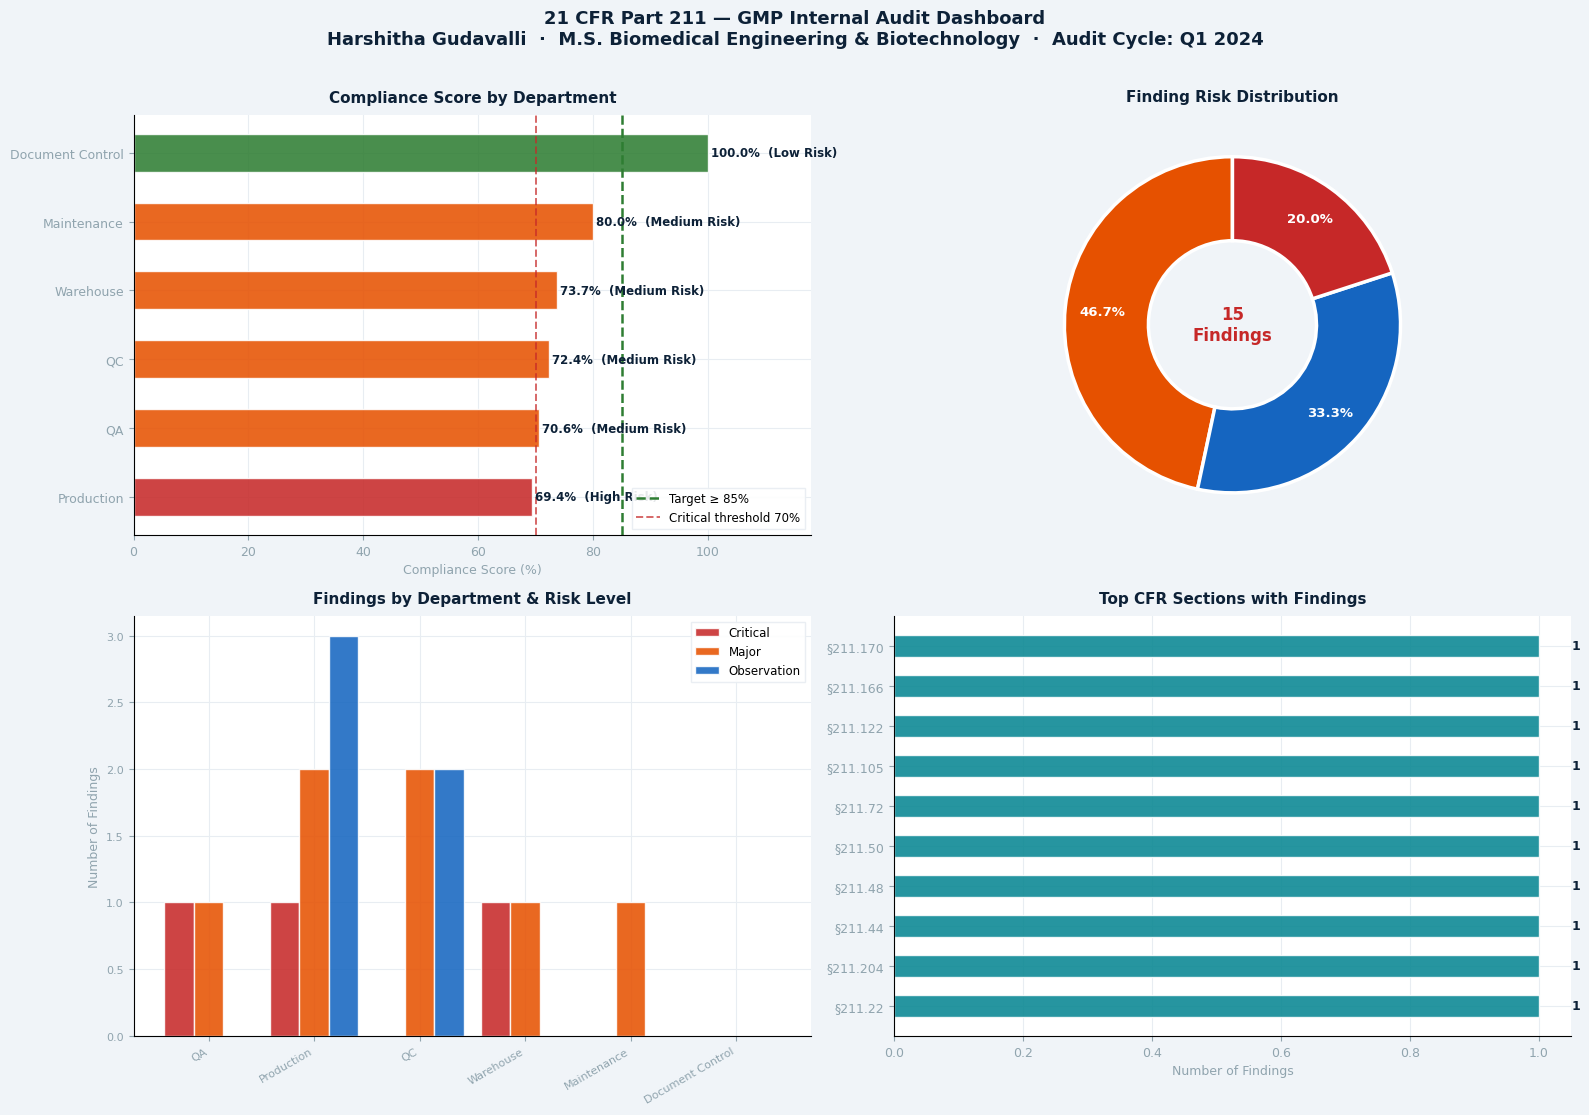

✔  Dashboard saved as AuditTracker_Dashboard_HGudavalli.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle(
    '21 CFR Part 211 — GMP Internal Audit Dashboard\n'
    'Harshitha Gudavalli  ·  M.S. Biomedical Engineering & Biotechnology  ·  Audit Cycle: Q1 2024',
    fontsize=13, fontweight='bold', color=C['navy'], y=1.01
)

ds = dept_scores.sort_values('Compliance_Pct')

# ── Chart 1: Department compliance scores ─────────────────────────────────────
ax = axes[0, 0]
bc = [C['red'] if v<70 else (C['amber'] if v<85 else C['green']) for v in ds['Compliance_Pct']]
bars = ax.barh(ds['Department'], ds['Compliance_Pct'], color=bc, alpha=0.87, height=0.55, edgecolor='white')
ax.axvline(85, color=C['green'], linestyle='--', linewidth=1.8, label='Target ≥ 85%')
ax.axvline(70, color=C['red'],   linestyle='--', linewidth=1.4, alpha=0.7, label='Critical threshold 70%')
for bar, val, rr in zip(bars, ds['Compliance_Pct'], ds['Risk_Rating']):
    ax.text(val+0.5, bar.get_y()+bar.get_height()/2,
            f'{val}%  ({rr})', va='center', fontsize=8.5, fontweight='bold', color=C['navy'])
ax.set_xlim(0, 118)
ax.set_xlabel('Compliance Score (%)', fontsize=9, color=C['gray'])
ax.set_title('Compliance Score by Department', fontsize=11, fontweight='bold', color=C['navy'], pad=9)
ax.legend(fontsize=8.5, framealpha=0.9, edgecolor='#E8EDF2', fancybox=False, loc='lower right')
ax.tick_params(colors=C['gray'], labelsize=9)
ax.set_axisbelow(True)

# ── Chart 2: Finding risk distribution donut ──────────────────────────────────
ax = axes[0, 1]
risk_cnt = fails['Risk_Level'].value_counts()
rcols    = {'Critical': C['red'], 'Major': C['amber'], 'Observation': C['blue']}
rcolors  = [rcols.get(r, '#999') for r in risk_cnt.index]
wedges, texts, autos = ax.pie(
    risk_cnt.values, colors=rcolors, autopct='%1.1f%%', startangle=90, pctdistance=0.78,
    wedgeprops=dict(width=0.50, edgecolor='white', linewidth=2.5))
for at in autos: at.set_fontsize(9.5); at.set_fontweight('bold'); at.set_color('white')
for t  in texts: t.set_fontsize(9); t.set_color(C['navy'])
ax.text(0, 0, f'{len(fails)}\nFindings', ha='center', va='center',
        fontsize=12, fontweight='bold', color=C['red'])
ax.set_title('Finding Risk Distribution', fontsize=11, fontweight='bold', color=C['navy'], pad=10)

# ── Chart 3: Findings by department stacked ───────────────────────────────────
ax = axes[1, 0]
dept_risk = fails.groupby(['Department','Risk_Level']).size().unstack(fill_value=0)
for col in ['Critical','Major','Observation']:
    if col not in dept_risk.columns: dept_risk[col] = 0
dept_risk = dept_risk.reindex(DEPARTMENTS).fillna(0)
x3 = np.arange(len(dept_risk))
w3 = 0.28
ax.bar(x3-w3, dept_risk['Critical'],     w3, color=C['red'],   alpha=0.87, label='Critical',    edgecolor='white')
ax.bar(x3,    dept_risk['Major'],        w3, color=C['amber'], alpha=0.87, label='Major',       edgecolor='white')
ax.bar(x3+w3, dept_risk['Observation'],  w3, color=C['blue'],  alpha=0.87, label='Observation', edgecolor='white')
ax.set_xticks(x3)
ax.set_xticklabels(dept_risk.index, rotation=30, ha='right', fontsize=8.5, color=C['gray'])
ax.set_ylabel('Number of Findings', fontsize=9, color=C['gray'])
ax.set_title('Findings by Department & Risk Level', fontsize=11, fontweight='bold', color=C['navy'], pad=9)
ax.legend(fontsize=8.5, framealpha=0.9, edgecolor='#E8EDF2', fancybox=False)
ax.tick_params(colors=C['gray'], labelsize=8)
ax.set_axisbelow(True)

# ── Chart 4: CFR section finding frequency ────────────────────────────────────
ax = axes[1, 1]
cfr_freq = fails['CFR_Section'].value_counts().head(10).sort_values()
bars4 = ax.barh([f'§{c}' for c in cfr_freq.index], cfr_freq.values,
                color=C['teal'], alpha=0.85, height=0.55, edgecolor='white')
for bar, val in zip(bars4, cfr_freq.values):
    ax.text(val+0.05, bar.get_y()+bar.get_height()/2,
            str(val), va='center', fontsize=9, fontweight='bold', color=C['navy'])
ax.set_xlabel('Number of Findings', fontsize=9, color=C['gray'])
ax.set_title('Top CFR Sections with Findings', fontsize=11, fontweight='bold', color=C['navy'], pad=9)
ax.tick_params(colors=C['gray'], labelsize=9)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('AuditTracker_Dashboard_HGudavalli.png', dpi=150, bbox_inches='tight')
plt.show()
print('✔  Dashboard saved as AuditTracker_Dashboard_HGudavalli.png')

---
## 6. Findings Log — All Non-Compliant Items

In [6]:
print('─' * 60)
print('  COMPLETE FINDINGS LOG')
print('─' * 60)
print(f'  Total findings  : {len(fails)}')
print(f'  Critical        : {len(fails[fails["Risk_Level"]=="Critical"])}')
print(f'  Major           : {len(fails[fails["Risk_Level"]=="Major"])}')
print(f'  Observation     : {len(fails[fails["Risk_Level"]=="Observation"])}')
print('─' * 60)

display_cols = ['Finding_ID','CFR_Section','Department','Risk_Level',
                'Weight','Compliant','Status','Audit_Date']
fails[display_cols].reset_index(drop=True)

────────────────────────────────────────────────────────────
  COMPLETE FINDINGS LOG
────────────────────────────────────────────────────────────
  Total findings  : 15
  Critical        : 3
  Major           : 7
  Observation     : 5
────────────────────────────────────────────────────────────


,Finding_ID,CFR_Section,Department,Risk_Level,Weight,Compliant,Status,Audit_Date
0,AUD-HG-0001,211.22,QA,Critical,3,No,Open,2024-03-04
1,AUD-HG-0002,211.204,QA,Major,2,No,Open,2024-03-04
2,AUD-HG-0003,211.44,Production,Observation,1,No,Open,2024-03-06
3,AUD-HG-0004,211.48,Production,Observation,2,No,Open,2024-03-06
4,AUD-HG-0005,211.50,Production,Major,1,No,Open,2024-03-06
5,AUD-HG-0006,211.72,Production,Observation,2,No,Open,2024-03-06
6,AUD-HG-0007,211.105,Production,Critical,2,No,Open,2024-03-06
7,AUD-HG-0008,211.122,Production,Major,3,No,Open,2024-03-06
8,AUD-HG-0009,211.166,QC,Observation,3,No,Open,2024-03-08
9,AUD-HG-0010,211.170,QC,Major,2,No,Open,2024-03-08


---
## 7. Excel Export — Professional Audit Report

In [7]:
OUTPUT  = 'AuditTracker_Report_HGudavalli.xlsx'
TODAY   = datetime.today().strftime('%Y-%m-%d')
AUTHOR  = 'Harshitha Gudavalli'

def thin_border():
    s = Side(style='thin', color='BFBFBF')
    return Border(left=s, right=s, top=s, bottom=s)

def hdr(ws, r, c, text, bg='0D2137', fg='FFFFFF', sz=10):
    cell           = ws.cell(r, c, text)
    cell.font      = Font(name='Calibri', size=sz, bold=True, color=fg)
    cell.fill      = PatternFill('solid', fgColor=bg)
    cell.alignment = Alignment(horizontal='center', vertical='center', wrap_text=True)
    cell.border    = thin_border()
    return cell

def body(ws, r, c, val, bg='FFFFFF', sz=9, bold=False, align='center'):
    cell           = ws.cell(r, c, val)
    cell.font      = Font(name='Calibri', size=sz, bold=bold)
    cell.fill      = PatternFill('solid', fgColor=bg)
    cell.alignment = Alignment(horizontal=align, vertical='center', wrap_text=True)
    cell.border    = thin_border()
    return cell

def banner(ws, ncols, row, text):
    ws.merge_cells(f'A{row}:{get_column_letter(ncols)}{row}')
    c = ws.cell(row, 1, text)
    c.font      = Font(name='Calibri', size=12, bold=True, color='FFFFFF')
    c.fill      = PatternFill('solid', fgColor='0D2137')
    c.alignment = Alignment(horizontal='center', vertical='center')
    ws.row_dimensions[row].height = 26

RISK_BG = {'Critical':'FFEBEE','Major':'FFF8E1','Observation':'E3F2FD','None':'E8F5E9'}
RISK_FG = {'Critical':'B71C1C','Major':'BF360C','Observation':'0D47A1','None':'1B5E20'}
COMP_BG = {'Yes':'E8F5E9','No':'FFEBEE'}
COMP_FG = {'Yes':'1B5E20','No':'B71C1C'}

wb = Workbook()

# ── Sheet 1: Full Audit Log ───────────────────────────────────────────────────
ws1 = wb.active
ws1.title = 'Full Audit Log'
banner(ws1, 12, 1, f'21 CFR PART 211 — FULL AUDIT LOG  ·  {AUTHOR}  ·  {TODAY}')

cols1 = ['Finding ID','CFR Section','Requirement','Department','Weight',
         'Compliant','Risk Level','Score','Max Score','Audit Date','Auditor','Status']
keys1 = ['Finding_ID','CFR_Section','Requirement','Department','Weight',
         'Compliant','Risk_Level','Score','Max_Score','Audit_Date','Auditor','Status']
wds1  = [14,12,42,18,9,10,12,9,10,13,14,12]

for ci,(h,w) in enumerate(zip(cols1,wds1),1):
    hdr(ws1,2,ci,h)
    ws1.column_dimensions[get_column_letter(ci)].width = w

for ri,(_,row) in enumerate(df.iterrows()):
    er  = 3+ri
    alt = 'F7FAFC' if ri%2==0 else 'FFFFFF'
    for ci,key in enumerate(keys1,1):
        val = row[key]
        if key=='Risk_Level':
            c = ws1.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=RISK_FG.get(val,'000000'))
            c.fill      = PatternFill('solid',fgColor=RISK_BG.get(val,'FFFFFF'))
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        elif key=='Compliant':
            c = ws1.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=COMP_FG.get(val,'000000'))
            c.fill      = PatternFill('solid',fgColor=COMP_BG.get(val,'FFFFFF'))
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        else:
            body(ws1,er,ci,val,bg=alt,align='left' if key=='Requirement' else 'center')

ws1.freeze_panes = 'A3'
ws1.auto_filter.ref = f'A2:{get_column_letter(len(cols1))}2'

# ── Sheet 2: Findings Only ────────────────────────────────────────────────────
ws2 = wb.create_sheet('Findings Log')
banner(ws2, 9, 1, f'FINDINGS LOG — {len(fails)} Non-Compliant Items  ·  21 CFR Part 211  ·  {AUTHOR}')

cols2 = ['Finding ID','CFR Section','Requirement','Department','Risk Level','Weight','Audit Date','Auditor','Status']
keys2 = ['Finding_ID','CFR_Section','Requirement','Department','Risk_Level','Weight','Audit_Date','Auditor','Status']
wds2  = [14,12,42,18,12,9,13,14,12]

for ci,(h,w) in enumerate(zip(cols2,wds2),1):
    hdr(ws2,2,ci,h)
    ws2.column_dimensions[get_column_letter(ci)].width = w

for ri,(_,row) in enumerate(fails.iterrows()):
    er  = 3+ri
    alt = 'F7FAFC' if ri%2==0 else 'FFFFFF'
    for ci,key in enumerate(keys2,1):
        val = row[key]
        if key=='Risk_Level':
            c = ws2.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=RISK_FG.get(val,'000000'))
            c.fill      = PatternFill('solid',fgColor=RISK_BG.get(val,'FFFFFF'))
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        elif key=='Status':
            c = ws2.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color='B71C1C')
            c.fill      = PatternFill('solid',fgColor='FFEBEE')
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        else:
            body(ws2,er,ci,val,bg=alt,align='left' if key=='Requirement' else 'center')

ws2.freeze_panes = 'A3'

# ── Sheet 3: Department Scorecard ─────────────────────────────────────────────
ws3 = wb.create_sheet('Department Scorecard')
banner(ws3, 9, 1, f'DEPARTMENT COMPLIANCE SCORECARD  ·  21 CFR Part 211  ·  {AUTHOR}  ·  {TODAY}')

cols3 = ['Department','Items Audited','Findings','Compliance %','Risk Rating','Critical','Major','Observation','Score / Max']
wds3  = [20,14,12,14,14,12,12,14,16]

for ci,(h,w) in enumerate(zip(cols3,wds3),1):
    hdr(ws3,2,ci,h)
    ws3.column_dimensions[get_column_letter(ci)].width = w

rr_bg = {'High Risk':'FFEBEE','Medium Risk':'FFF8E1','Low Risk':'E8F5E9'}
rr_fg = {'High Risk':'B71C1C','Medium Risk':'BF360C','Low Risk':'1B5E20'}

for ri,(_,row) in enumerate(dept_scores.sort_values('Compliance_Pct').iterrows()):
    er  = 3+ri
    alt = 'F7FAFC' if ri%2==0 else 'FFFFFF'
    vals = [
        row['Department'], row['Items'], row['Findings'],
        f"{row['Compliance_Pct']}%", row['Risk_Rating'],
        row['Critical'], row['Major'], row['Observation'],
        f"{row['Total_Score']}/{row['Max_Score']}"
    ]
    for ci,(val,key) in enumerate(zip(vals,['dept','items','findings','comp','risk','crit','maj','obs','score']),1):
        if key=='risk':
            c = ws3.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=rr_fg.get(val,'000000'))
            c.fill      = PatternFill('solid',fgColor=rr_bg.get(val,'FFFFFF'))
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        elif key=='comp':
            pct = float(str(val).replace('%',''))
            fg  = '1B5E20' if pct>=85 else ('BF360C' if pct<70 else '856404')
            c   = ws3.cell(er,ci,val)
            c.font      = Font(name='Calibri',size=9,bold=True,color=fg)
            c.fill      = PatternFill('solid',fgColor=alt)
            c.alignment = Alignment(horizontal='center',vertical='center')
            c.border    = thin_border()
        else:
            body(ws3,er,ci,val,bg=alt)

# Overall row
er = 3+len(dept_scores)
ws3.merge_cells(f'A{er}:D{er}')
c = ws3.cell(er,1,f'OVERALL COMPLIANCE: {overall}%')
c.font      = Font(name='Calibri',size=10,bold=True,color='FFFFFF')
c.fill      = PatternFill('solid',fgColor='1E3A5F')
c.alignment = Alignment(horizontal='center',vertical='center')
c.border    = thin_border()

# Bar chart
chart = BarChart()
chart.type   = 'col'
chart.title  = 'Department Compliance Score (%)'
chart.style  = 10
chart.width  = 22
chart.height = 12
chart.add_data(Reference(ws3,min_col=4,max_col=4,min_row=2,max_row=2+len(dept_scores)),titles_from_data=True)
chart.set_categories(Reference(ws3,min_col=1,min_row=3,max_row=2+len(dept_scores)))
ws3.add_chart(chart,f'A{7+len(dept_scores)}')

# ── Sheet 4: Executive Summary ────────────────────────────────────────────────
ws4 = wb.create_sheet('Executive Summary')
banner(ws4, 4, 1, f'EXECUTIVE AUDIT SUMMARY  ·  21 CFR Part 211 (cGMP)  ·  {AUTHOR}')

summary_data = [
    ('Audit Cycle',             'Q1 2024'),
    ('Auditor',                 AUTHOR),
    ('Regulatory Standard',     '21 CFR Part 211 — cGMP'),
    ('Departments Audited',     str(len(DEPARTMENTS))),
    ('Total Requirements',      str(len(df))),
    ('Compliant Items',         str(len(df[df['Compliant']=='Yes']))),
    ('Total Findings',          str(len(fails))),
    ('Critical Findings',       str(len(fails[fails['Risk_Level']=='Critical']))),
    ('Major Findings',          str(len(fails[fails['Risk_Level']=='Major']))),
    ('Observations',            str(len(fails[fails['Risk_Level']=='Observation']))),
    ('Overall Compliance',      f'{overall}%'),
    ('Report Generated',        TODAY),
]

ws4.column_dimensions['A'].width = 26
ws4.column_dimensions['B'].width = 30

for ri,(label,val) in enumerate(summary_data):
    er = 3+ri
    alt = 'F7FAFC' if ri%2==0 else 'FFFFFF'
    lc = ws4.cell(er,1,label)
    lc.font      = Font(name='Calibri',size=10,bold=True,color='0D2137')
    lc.fill      = PatternFill('solid',fgColor=alt)
    lc.alignment = Alignment(horizontal='left',vertical='center')
    lc.border    = thin_border()
    vc = ws4.cell(er,2,val)
    vc.font      = Font(name='Calibri',size=10,color='1E3A5F')
    vc.fill      = PatternFill('solid',fgColor=alt)
    vc.alignment = Alignment(horizontal='left',vertical='center')
    vc.border    = thin_border()
    ws4.row_dimensions[er].height = 18

wb.save(OUTPUT)
print(f'✔  Report saved: {OUTPUT}')
print(f'   Sheets: {[s.title for s in wb.worksheets]}')

try:
    from google.colab import files
    files.download(OUTPUT)
    print('✔  Download started.')
except:
    print('   (Open file from the Colab left sidebar → Files)')

✔  Report saved: AuditTracker_Report_HGudavalli.xlsx
   Sheets: ['Full Audit Log', 'Findings Log', 'Department Scorecard', 'Executive Summary']


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✔  Download started.


---
## 8. Final Summary

In [8]:
d = '─' * 58
print(d)
print('  PROJECT SUMMARY — Project 3')
print('  Harshitha Gudavalli')
print('  M.S. Biomedical Engineering & Biotechnology')
print(d)
print(f'  Regulatory standard    :  21 CFR Part 211 (cGMP)')
print(f'  Departments audited    :  {len(DEPARTMENTS)}')
print(f'  Requirements audited   :  {len(df)}')
print(f'  Total findings         :  {len(fails)}')
print(f'  Overall compliance     :  {overall}%')
print()
print('  Findings breakdown:')
for r in ['Critical','Major','Observation']:
    print(f'    {r:<14}  {len(fails[fails["Risk_Level"]==r])}')
print()
print('  Output files:')
print(f'    ✔  {OUTPUT}')
print(f'    ✔  AuditTracker_Dashboard_HGudavalli.png')
print(d)
print()
print('  Resume bullet:')
print('  "Built a 21 CFR Part 211 internal audit tracking')
print('  system evaluating 55 GMP requirements across 6')
print('  departments — risk-rated findings as Critical,')
print('  Major, or Observation, calculated weighted compliance')
print('  scores per department, and generated an audit')
print('  summary report with embedded compliance charts."')
print(d)

──────────────────────────────────────────────────────────
  PROJECT SUMMARY — Project 3
  Harshitha Gudavalli
  M.S. Biomedical Engineering & Biotechnology
──────────────────────────────────────────────────────────
  Regulatory standard    :  21 CFR Part 211 (cGMP)
  Departments audited    :  6
  Requirements audited   :  55
  Total findings         :  15
  Overall compliance     :  75.9%

  Findings breakdown:
    Critical        3
    Major           7
    Observation     5

  Output files:
    ✔  AuditTracker_Report_HGudavalli.xlsx
    ✔  AuditTracker_Dashboard_HGudavalli.png
──────────────────────────────────────────────────────────

  Resume bullet:
  "Built a 21 CFR Part 211 internal audit tracking
  system evaluating 55 GMP requirements across 6
  departments — risk-rated findings as Critical,
  Major, or Observation, calculated weighted compliance
  scores per department, and generated an audit
  summary report with embedded compliance charts."
────────────────────────────────